# Lab 15:

---
## Introduction to Transfer Learning
In our previous lab, we built a Convolutional Neural Network (CNN) from scratch. While effective for simpler tasks, training deep networks from scratch requires massive datasets and significant computational power.

**Transfer Learning** allows us to take a model that has already been trained on a massive dataset (like ImageNet, which contains millions of images across 1000 categories) and repurpose it for our own specific task (like detecting malaria in cell images).

### Key Concepts:
1. **Pre-trained Model (The Base):** We will import **VGG16**, a famous and powerful deep CNN architecture. We will load the weights it learned from the ImageNet dataset.
2. **Importing the Model:** PyTorch provides built-in modules (`torchvision.models`) to download these architectures.
3. **Freezing Layers:** We "freeze" the base model (`requires_grad = False`) to keep its weights intact while we train only our new custom head.
4. **Replacing the Head:** Pre-trained models are typically designed to output 1000 classes. We will replace the final classification layers (the "head") with our own layers designed for binary classification.
5. **Fine-Tuning:** Once our custom head is trained, we can optionally "unfreeze" the top few layers of the base model and train the whole system with a very low learning rate.

### Task 1: Import Necessary Libraries
Import PyTorch, Torchvision, and other necessary libraries for data loading and visualization.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
import os
import urllib.request
import zipfile
import random
import shutil


dataset_url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
zip_path = "cell_images.zip"
original_dataset_dir = "cell_images"
base_dir = "./Malaria_Dataset"


if not os.path.exists(zip_path) and not os.path.exists(base_dir):
    print("Downloading Malaria dataset. Please wait...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Download complete!")


if not os.path.exists(original_dataset_dir) and not os.path.exists(base_dir):
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete!")


if not os.path.exists(base_dir):
    print("Creating train/val split structure...")
    classes = ['Parasitized', 'Uninfected']

    # Create the folder structure
    for split in ['train', 'val']:
        for cls in classes:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)


    split_ratio = 0.8
    for cls in classes:
        src_dir = os.path.join(original_dataset_dir, cls)
        filenames = os.listdir(src_dir)


        filenames = [f for f in filenames if f.endswith('.png')]


        random.shuffle(filenames)


        split_idx = int(len(filenames) * split_ratio)
        train_files = filenames[:split_idx]
        val_files = filenames[split_idx:]


        for f in train_files:
            shutil.copy(os.path.join(src_dir, f), os.path.join(base_dir, 'train', cls, f))


        for f in val_files:
            shutil.copy(os.path.join(src_dir, f), os.path.join(base_dir, 'val', cls, f))

    print("Dataset successfully organized into ./Malaria_Dataset/train and ./Malaria_Dataset/val")
else:
    print("Dataset already downloaded and organized!")

Download complete!
Extracting files...
Extraction complete!
Creating train/val split structure...
Dataset successfully organized into ./Malaria_Dataset/train and ./Malaria_Dataset/val



# PART 1

In [3]:

print("Loading VGG16...")
vgg16_full = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_full = vgg16_full.to(device)
vgg16_full.eval()

Loading VGG16...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 80.7MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [8]:
import json,requests

labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
imagenet_labels = json.loads(requests.get(labels_url).text)

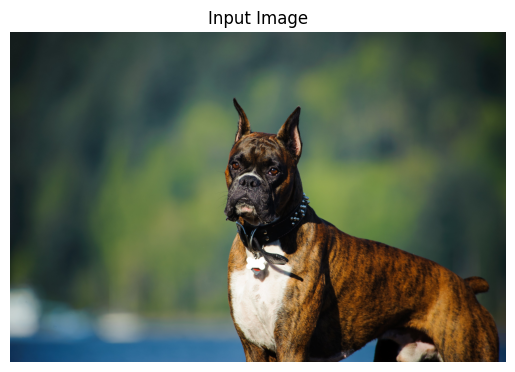

In [14]:
import io
import requests # Ensure requests is imported
from PIL import Image

# Download a sample image of a dog from a reliable source
img_url = "https://cdn.shopify.com/s/files/1/0582/8349/1478/files/portrait-dog-standing-against-trees.jpg?v=1744717401"

response = requests.get(img_url)

# Check if the request was successful
if response.status_code != 200:
    raise Exception(f"Failed to download image from {img_url}. Status code: {response.status_code}")


content_type = response.headers.get('Content-Type', '')
if not content_type.startswith('image'):
    raise Exception(f"URL content is not an image. Content-Type: {content_type}")

img = Image.open(io.BytesIO(response.content))

plt.imshow(img)
plt.axis('off')
plt.title("Input Image")
plt.show()


In [17]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0).to(device)
input_batch

tensor([[[[-1.2103, -1.2274, -1.2103,  ..., -1.0904, -1.1418, -1.1418],
          [-1.2103, -1.2274, -1.2274,  ..., -1.0733, -1.1075, -1.1418],
          [-1.2103, -1.2103, -1.2274,  ..., -1.0562, -1.0904, -1.1247],
          ...,
          [-0.0629, -0.0116,  0.0569,  ..., -1.6213, -1.6213, -1.6555],
          [-0.1828, -0.1314, -0.0972,  ..., -1.5870, -1.6042, -1.6213],
          [-0.3198, -0.2684, -0.2342,  ..., -1.5699, -1.5870, -1.6042]],

         [[-0.7752, -0.7577, -0.7577,  ..., -0.6877, -0.7402, -0.7577],
          [-0.7752, -0.7577, -0.7577,  ..., -0.6877, -0.7227, -0.7577],
          [-0.7577, -0.7402, -0.7577,  ..., -0.6702, -0.7052, -0.7402],
          ...,
          [ 0.5203,  0.5553,  0.6078,  ..., -1.6331, -1.6331, -1.6681],
          [ 0.4328,  0.4678,  0.5028,  ..., -1.6155, -1.6155, -1.6506],
          [ 0.3452,  0.3978,  0.4153,  ..., -1.6155, -1.5980, -1.6155]],

         [[-0.6541, -0.6541, -0.6367,  ..., -0.6715, -0.6890, -0.7064],
          [-0.6541, -0.6541, -

In [18]:
with torch.no_grad():
  output = vgg16_full(input_batch)

  probabilities = torch.nn.functional.softmax(output[0],dim=0)

  top3_prob, top3_catid = torch.topk(probabilities,3)

  print("\nTop 3 Prdiction")
  for i in range(top3_prob.size(0)):
    class_name = imagenet_labels[top3_catid[i]]
    confidance = top3_prob[i].item()*100
    print(f"{i+1}. {class_name}: {confidance:.2f}%")


Top 3 Prdiction
1. Boxer: 98.86%
2. Bullmastiff: 0.57%
3. muzzle: 0.17%



# PART 2

### Task 2: Data Augmentation and Loading
Initialize transformations (rescaling to 0-1 via `ToTensor()`, resizing, and adding random augmentations). Use `datasets.ImageFolder` and `DataLoader` to load the Train and Test sets.

tensor([[[[-1.2103, -1.2274, -1.2103,  ..., -1.0904, -1.1418, -1.1418],
          [-1.2103, -1.2274, -1.2274,  ..., -1.0733, -1.1075, -1.1418],
          [-1.2103, -1.2103, -1.2274,  ..., -1.0562, -1.0904, -1.1247],
          ...,
          [-0.0629, -0.0116,  0.0569,  ..., -1.6213, -1.6213, -1.6555],
          [-0.1828, -0.1314, -0.0972,  ..., -1.5870, -1.6042, -1.6213],
          [-0.3198, -0.2684, -0.2342,  ..., -1.5699, -1.5870, -1.6042]],

         [[-0.7752, -0.7577, -0.7577,  ..., -0.6877, -0.7402, -0.7577],
          [-0.7752, -0.7577, -0.7577,  ..., -0.6877, -0.7227, -0.7577],
          [-0.7577, -0.7402, -0.7577,  ..., -0.6702, -0.7052, -0.7402],
          ...,
          [ 0.5203,  0.5553,  0.6078,  ..., -1.6331, -1.6331, -1.6681],
          [ 0.4328,  0.4678,  0.5028,  ..., -1.6155, -1.6155, -1.6506],
          [ 0.3452,  0.3978,  0.4153,  ..., -1.6155, -1.5980, -1.6155]],

         [[-0.6541, -0.6541, -0.6367,  ..., -0.6715, -0.6890, -0.7064],
          [-0.6541, -0.6541, -

### Task 3: Load Base Model and Freeze Layers
Load the pre-trained VGG16 model. Iterate through its parameters and turn off gradients so the weights don't update during the initial training phase.

In [19]:

# Load pre-trained VGG16
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for params in vgg16.parameters():
  params.requires_grad = False


### Task 4: Add Custom Head (Classifier)
Replace `vgg16.classifier` with a new `nn.Sequential` block containing a Linear layer (e.g., 256 units), a ReLU activation, and a final Linear layer for our binary output.

In [ ]:

num_features = vgg16.classifier[0].in_features


vgg16.classifier = nn.Sequential(

)


vgg16 = vgg16.to(device)


print(vgg16)

### Task 5: Define Loss Function and Optimizer
Define the criterion (Loss Function). Set up the optimizer (e.g., Adam) to *only* update the parameters of the new classifier we just added.

### Task 6: Train the Model
Create the PyTorch training loop. Iterate over the epochs, perform forward passes, calculate the loss, backpropagate, and update the optimizer steps. Keep track of training and validation accuracy.

### Task 7: Plot History
Visualize the Training vs. Validation Accuracy and Loss using Matplotlib to check for overfitting or underfitting.

### Task 8: Fine Tuning (Optional)
Now that our custom head is trained, let's unfreeze the last convolutional block of VGG16. We will compile a new optimizer with a much **lower** learning rate so we don't drastically alter the pre-trained weights, and retrain the model for a few more epochs.